In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import digamma, logsumexp
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import adjusted_rand_score
from scipy.special import digamma, logsumexp, gammaln


class VARISEM:
    def __init__(self, X, K, max_iter=300, tol=1e-6):
        self.X = X
        self.N, self.D = X.shape
        self.K = K
        self.max_iter = max_iter
        self.tol = tol

        self.alpha_prior = np.ones(K) * 10  
        self.a_prior = np.ones((K, D)) * 5  
        self.b_prior = np.ones((K, D)) * 10  

        bmm = BayesianGaussianMixture(
            n_components=K, covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            random_state=42, max_iter=100, n_init=10
        )
        bmm.fit(X)
        self.q_nk = bmm.predict_proba(X)  

        #self.alpha_q = self.alpha_prior.copy()
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.a_q = self.a_prior.copy() + np.dot(self.q_nk.T, self.X)
        self.b_q = self.b_prior.copy() + np.dot(self.q_nk.T, 1 - self.X)

    def update_q_nk(self):
        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        log_q_nk = log_pi_k + np.sum(
            self.X[:, None, :] * log_mu_ki[None, :, :] + (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :],
            axis=2
        )

        log_q_nk -= logsumexp(log_q_nk, axis=1, keepdims=True)
        self.q_nk = np.exp(log_q_nk)

    def update_pi_k(self):
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.pi_k_mean = self.alpha_q / np.sum(self.alpha_q)

    def update_mu_ki(self):
        self.a_q = self.a_prior + np.dot(self.q_nk.T, self.X)
        self.b_q = self.b_prior + np.dot(self.q_nk.T, 1 - self.X)
        self.mu_ki_mean = self.a_q / (self.a_q + self.b_q)
        
    def compute_elbo(self):
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        log_likelihood = np.sum(self.q_nk[:, :, None] * (
            self.X[:, None, :] * log_mu_ki[None, :, :] +
            (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :]
        ))

        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))

        log_prior_z = np.sum(self.q_nk * log_pi_k)
        log_prior_pi = np.sum((self.alpha_prior - 1) * log_pi_k)
        log_prior_mu = np.sum((self.a_prior - 1) * log_mu_ki + (self.b_prior - 1) * log_1_mu_ki)

        entropy_q_z = -np.sum(self.q_nk * np.log(self.q_nk + 1e-10))

        alpha_0 = np.sum(self.alpha_q)
        dirichlet_entropy = (
            gammaln(alpha_0) - np.sum(gammaln(self.alpha_q))
            + (alpha_0 - self.K) * digamma(alpha_0)
            - np.sum((self.alpha_q - 1) * digamma(self.alpha_q))
        )

        beta_entropy = np.sum(
            gammaln(self.a_q + self.b_q) - gammaln(self.a_q) - gammaln(self.b_q)
            - (self.a_q - 1) * digamma(self.a_q)
            - (self.b_q - 1) * digamma(self.b_q)
            + (self.a_q + self.b_q - 2) * digamma(self.a_q + self.b_q)
        )

        elbo = (
            log_likelihood
            + log_prior_z
            + log_prior_pi
            + log_prior_mu
            + entropy_q_z
            + dirichlet_entropy
            + beta_entropy
        )

        return elbo  # <-- Proper indentation

    def fit(self):
        elbo_old = -np.inf
        self.elbo_values = []

        for iteration in range(self.max_iter):
            self.update_q_nk()
            self.update_pi_k()
            self.update_mu_ki()

            elbo = self.compute_elbo()
            self.elbo_values.append(elbo)

            if np.abs(elbo - elbo_old) < self.tol:
                print(f"Converged at iteration {iteration}.")
                break
            elbo_old = elbo

            if iteration % 10 == 0:
                print(f"Iteration {iteration}, ELBO: {elbo:.4f}")

        print("Optimization complete.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.metrics import adjusted_rand_score

class DREEM:
    def __init__(self, X, K, max_iter=100, tol=1e-6):
        self.X = X
        self.N, self.D = X.shape
        self.K = K
        self.max_iter = max_iter
        self.tol = tol

        # Initialize parameters
        self.pi = np.ones(K) / K  # Uniform cluster proportions
        self.mu = np.random.rand(K, self.D)  # Random mutation probabilities
        self.responsibilities = np.zeros((self.N, self.K))  # Cluster responsibilities
        self.log_likelihoods = []

    def e_step(self):
        log_likelihood = np.zeros((self.N, self.K))
        for k in range(self.K):
            log_likelihood[:, k] = np.sum(
                self.X * np.log(np.clip(self.mu[k], 1e-10, 1 - 1e-10)) +
                (1 - self.X) * np.log(np.clip(1 - self.mu[k], 1e-10, 1 - 1e-10)),
                axis=1
            ) + np.log(self.pi[k] + 1e-10)

        log_responsibilities = log_likelihood - logsumexp(log_likelihood, axis=1, keepdims=True)
        self.responsibilities = np.exp(log_responsibilities)

    def m_step(self):
        N_k = np.sum(self.responsibilities, axis=0)
        self.pi = N_k / self.N
        for k in range(self.K):
            self.mu[k] = np.sum(self.responsibilities[:, k, None] * self.X, axis=0) / (N_k[k] + 1e-10)

    def compute_log_likelihood(self):
        log_likelihood = np.zeros((self.N, self.K))
        for k in range(self.K):
            log_likelihood[:, k] = np.sum(
                self.X * np.log(np.clip(self.mu[k], 1e-10, 1 - 1e-10)) +
                (1 - self.X) * np.log(np.clip(1 - self.mu[k], 1e-10, 1 - 1e-10)),
                axis=1
            ) + np.log(self.pi[k] + 1e-10)
        return np.sum(logsumexp(log_likelihood, axis=1))

    def fit(self):
        log_likelihood_old = -np.inf
        for iteration in range(self.max_iter):
            self.e_step()
            self.m_step()

            log_likelihood = self.compute_log_likelihood()
            self.log_likelihoods.append(log_likelihood)

            if np.abs(log_likelihood - log_likelihood_old) < self.tol:
                print(f"Converged at iteration {iteration}.")
                break
            log_likelihood_old = log_likelihood
        print("Optimization complete.")

    def predict(self):
        return np.argmax(self.responsibilities, axis=1)

In [ ]:
def kl_bernoulli(p, q, epsilon=1e-10):
    p = np.clip(p, epsilon, 1 - epsilon)
    q = np.clip(q, epsilon, 1 - epsilon)
    kl = p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))
    return np.sum(kl)

In [ ]:
import os
output_folder = "k=3"
os.makedirs(output_folder, exist_ok=True)

D_values = np.arange(50, 850, 50)
N_values = [50, 100, 150, 200, 250, 300, 400, 500, 600, 800,1000]

results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 3
        alpha = np.ones(K) * 2

        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        vi_model_bmm_mean = VARISEM(X_D, K, max_iter=300, tol=1e-6)
        vi_model_bmm_mean.fit()

        Z_pred = np.argmax(vi_model_bmm_mean.q_nk, axis=1)
        ari_score = adjusted_rand_score(Z_true, Z_pred)

        pi_estimated = vi_model_bmm_mean.pi_k_mean
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Compute KL divergence for mu
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], vi_model_bmm_mean.mu_ki_mean[k, :])
            kl_divergences.append(kl_k)
        kl_divergence_mean = np.mean(kl_divergences)

        results.append([D, N, ari_score, pi_mae, kl_divergence_mean])

# Create DataFrame
df_results = pd.DataFrame(results, columns=["D", "N", "ARI", "pi_MAE", "mu_KL"])
filename_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=3.csv")
df_results.to_csv(filename_csv, index=False)

In [ ]:
results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 3
        alpha = np.ones(K) * 2

        # Generate true parameters
        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        # Run DREEM
        dreem_model = DREEM(X_D, K, max_iter=300, tol=1e-6)
        dreem_model.fit()

        Z_pred_dreem = dreem_model.predict()
        ari_dreem = adjusted_rand_score(Z_true, Z_pred_dreem)

        # Calculate pi MAE
        pi_estimated = dreem_model.pi
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Calculate mu KL divergence
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], dreem_model.mu[k, :])
            kl_divergences.append(kl_k)
        mu_kl = np.mean(kl_divergences)

        results.append([D, N, ari_dreem, pi_mae, mu_kl])


df_results = pd.DataFrame(results, columns=["D", "N", "ARI_DREEM", "pi_MAE_DREEM", "mu_KL_DREEM"])
filename_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=3.csv")
df_results.to_csv(filename_csv, index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
output_folder = "k=3"
filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=3.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=3.csv")
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)
df_combined["ARI_DREEM"] = df_combined["ARI_DREEM"].clip(lower=0)
df_combined["ARI"] = df_combined["ARI"].clip(lower=0)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Setup
bar_width = 0.35
x_positions = np.arange(len(df_summary["D"]))

plt.figure(figsize=(12, 6))

# Plot DREEM ARI
plt.bar(
    x_positions - bar_width / 2,
    df_summary["ARI_DREEM_mean"],
    yerr=[
        df_summary["ARI_DREEM_min_err"],
        df_summary["ARI_DREEM_max_err"]
    ],
    capsize=5,
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM ARI
plt.bar(
    x_positions + bar_width / 2,
    df_summary["ARI_VARISEM_mean"],
    yerr=[
        df_summary["ARI_VARISEM_min_err"],
        df_summary["ARI_VARISEM_max_err"]
    ],
    capsize=5,
    color="#f78779",  
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)


# Labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Comparison of ARI vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.xticks(x_positions, df_summary["D"], rotation=45, fontsize=10)

plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")

# Save and show the plot
plt.tight_layout()                  
filename = os.path.join(output_folder, "ARI_VARISEM_vs_DREEM_k=3.pdf")
plt.savefig(filename, format='pdf')
plt.show()

In [ ]:
import seaborn as sns

# Seaborn styling for cleaner visuals
sns.set(style="whitegrid")

# -------------------------
# Prepare long format for pi_MAE and mu_KL
# -------------------------

# Melt pi_MAE columns into long format
df_long_pi_mae = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["pi_MAE_DREEM", "pi_MAE"],
    var_name="Model",
    value_name="pi_MAE_value"  # unique name to avoid conflict
)

# Clean up model names
df_long_pi_mae["Model"] = df_long_pi_mae["Model"].replace({
    "pi_MAE_DREEM": "DREEM",
    "pi_MAE": "VARISEM"
})

# Melt mu_KL columns into long format
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM", "mu_KL"],
    var_name="Model",
    value_name="mu_KL_value"  # unique name to avoid conflict
)

df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM": "DREEM",
    "mu_KL": "VARISEM"
})

# -------------------------
# Plot pi_MAE
# -------------------------

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    width=0.6
)
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Box Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
filename = os.path.join(output_folder, "pi_boxplot_k=3.pdf")
plt.savefig(filename, format='pdf')    
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner="quart",
    scale="count"
)
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
filename = os.path.join(output_folder, "pi_violinplot_k=3.pdf")
plt.savefig(filename, format='pdf')    
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count"
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1, mean, q3
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(mean, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1, mean, q3
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(mean, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "pi_violinplot_with_3lines_and_iqr_k=3.pdf")
plt.savefig(filename, format='pdf')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count",
    cut=0,
    bw_adjust=2
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean#d8b03c
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)


plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "pi_violinplot_with_3lines_and_iqr_mean_dot_k=3.pdf")
plt.savefig(filename, format='pdf')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count"
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean#d8b03c
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)


plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "pi_violinplot_with_3lines_and_iqr_mean_dot_k=3.pdf")
plt.savefig(filename, format='pdf')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

output_folder = "k=3"
filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=3.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=3.csv")
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)
# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Step 1: Normalize mu_KL values per D group
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten the columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max across both methods for each D
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize the mu_KL values (row-level)
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Step 2: Convert into long format for plotting
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM_norm", "mu_KL_VARISEM_norm"],
    var_name="Model",
    value_name="mu_KL_norm"
)

# Rename model labels
df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM_norm": "DREEM",
    "mu_KL_VARISEM_norm": "VARISEM"
})



# Step 3: Create violin plot with IQR lines and mean dots
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_mu_kl,
    x="D",
    y="mu_KL_norm",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,
    scale="count"
)

# Summary statistics for each D and Model
summary = df_long_mu_kl.groupby(["D", "Model"]).agg(
    q1=("mu_KL_norm", lambda x: np.percentile(x, 25)),
    q3=("mu_KL_norm", lambda x: np.percentile(x, 75)),
    mean=("mu_KL_norm", "mean")
).reset_index()

# Plot parameters
spacing = 0.1
line_length = 0.2

# Loop through each D value
for i, d in enumerate(sorted(df_long_mu_kl["D"].unique())):
    # DREEM (left)
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # VARISEM (right)
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Customize plot labels and grid
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Violin Plot of Normalized KL Divergence vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.grid(axis='y', linestyle="--", alpha=0.7)

plt.legend(title="Model", loc="upper left")
plt.tight_layout()

# Save the plot
output_folder = "k=3"
filename = os.path.join(output_folder, "mu_KL_violinplot_with_3lines_and_mean_dot_k=3.pdf")
plt.savefig(filename, format='pdf')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

output_folder = "k=3"
filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=3.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=3.csv")
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)
# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Step 1: Normalize mu_KL values per D group
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten the columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max across both methods for each D
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize the mu_KL values (row-level)
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Step 2: Convert into long format for plotting
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM_norm", "mu_KL_VARISEM_norm"],
    var_name="Model",
    value_name="mu_KL_norm"
)

# Rename model labels
df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM_norm": "DREEM",
    "mu_KL_VARISEM_norm": "VARISEM"
})
# Filter out points at exactly 0 or 1 (to avoid extreme tails and distortions)
df_long_mu_kl_filtered = df_long_mu_kl[
    (df_long_mu_kl["mu_KL_norm"] > 0) & 
    (df_long_mu_kl["mu_KL_norm"] < 1)
].copy()

plt.figure(figsize=(14, 6))

ax = sns.boxenplot(
    data=df_long_mu_kl_filtered,
    x="D",
    y="mu_KL_norm",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    width=0.5,
    dodge=True
)

plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Boxen Plot of Normalized KL Divergence vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper right")
plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(14, 6))

ax = sns.boxenplot(
    data=df_long_mu_kl_filtered,
    x="D",
    y="mu_KL_norm",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    width=0.5,
    dodge=True,
    showfliers=False   # <<< This disables drawing of outliers!
)

plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Boxen Plot of Normalized KL Divergence vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper right")
plt.tight_layout()

plt.show()



In [ ]:
plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=df_long_mu_kl_filtered,
    x="D",
    y="mu_KL_norm",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    width=0.5,
    dodge=True,
    showfliers=False  # <<< No outliers!
)

plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Box Plot of Normalized KL Divergence vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()
filename = os.path.join(output_folder, "Figure1B.pdf")
plt.savefig(filename, format='pdf')
plt.show()


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
output_folder = "k=3"
filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=3.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=3.csv")
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)
df_combined["ARI_DREEM"] = df_combined["ARI_DREEM"].clip(lower=0)
df_combined["ARI"] = df_combined["ARI"].clip(lower=0)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

In [9]:
# Melt pi_MAE columns into long format
df_long_pi_mae = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["pi_MAE_DREEM", "pi_MAE"],
    var_name="Model",
    value_name="pi_MAE_value"  # unique name to avoid conflict
)

# Clean up model names
df_long_pi_mae["Model"] = df_long_pi_mae["Model"].replace({
    "pi_MAE_DREEM": "DREEM",
    "pi_MAE": "VARISEM"
})

# Melt mu_KL columns into long format
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM", "mu_KL"],
    var_name="Model",
    value_name="mu_KL_value"  # unique name to avoid conflict
)

df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM": "DREEM",
    "mu_KL": "VARISEM"
})


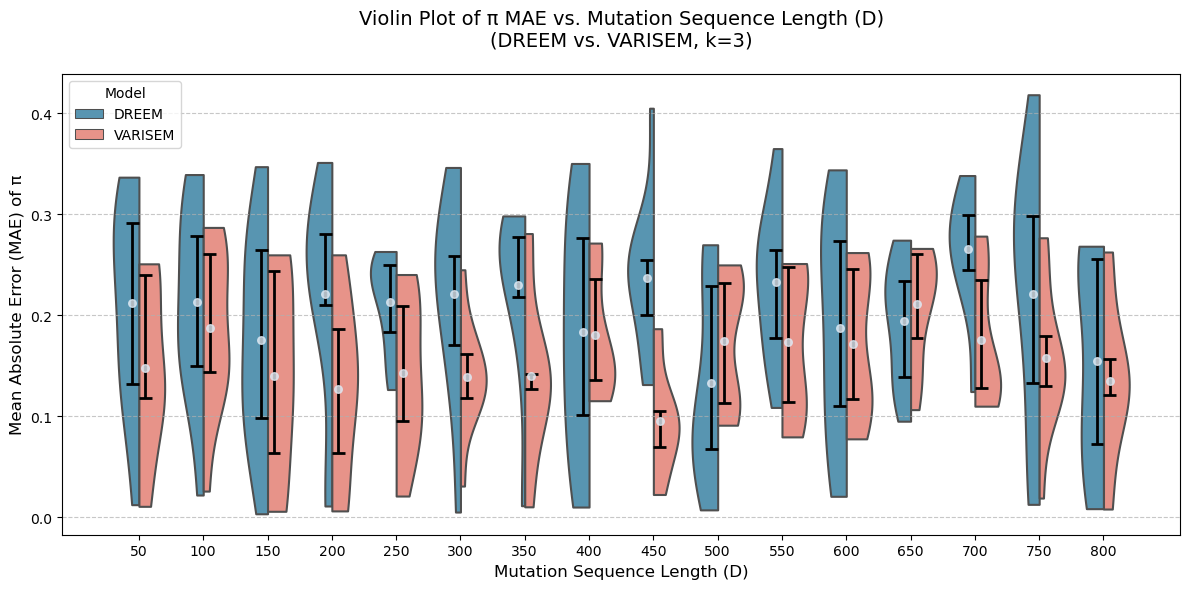

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count",
    cut=0,
    bw_adjust=2
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean#d8b03c
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)


plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "Figure1C2.pdf")
plt.savefig(filename, format='pdf')
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
output_folder = "k=4"
filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=4.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=4.csv")
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)
df_combined["ARI_DREEM"] = df_combined["ARI_DREEM"].clip(lower=0)
df_combined["ARI"] = df_combined["ARI"].clip(lower=0)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

In [2]:
# Melt pi_MAE columns into long format
df_long_pi_mae = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["pi_MAE_DREEM", "pi_MAE"],
    var_name="Model",
    value_name="pi_MAE_value"  # unique name to avoid conflict
)

# Clean up model names
df_long_pi_mae["Model"] = df_long_pi_mae["Model"].replace({
    "pi_MAE_DREEM": "DREEM",
    "pi_MAE": "VARISEM"
})

# Melt mu_KL columns into long format
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM", "mu_KL"],
    var_name="Model",
    value_name="mu_KL_value"  # unique name to avoid conflict
)

df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM": "DREEM",
    "mu_KL": "VARISEM"
})


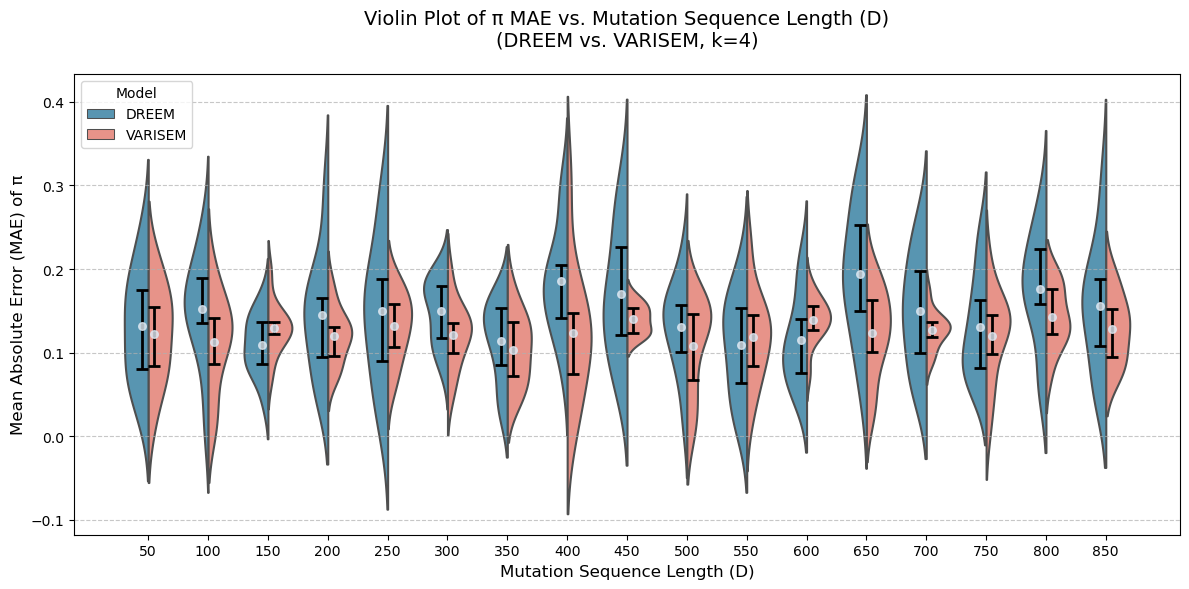

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count"
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean#d8b03c
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)


plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "Figure2C1.pdf")
plt.savefig(filename, format='pdf')
plt.show()


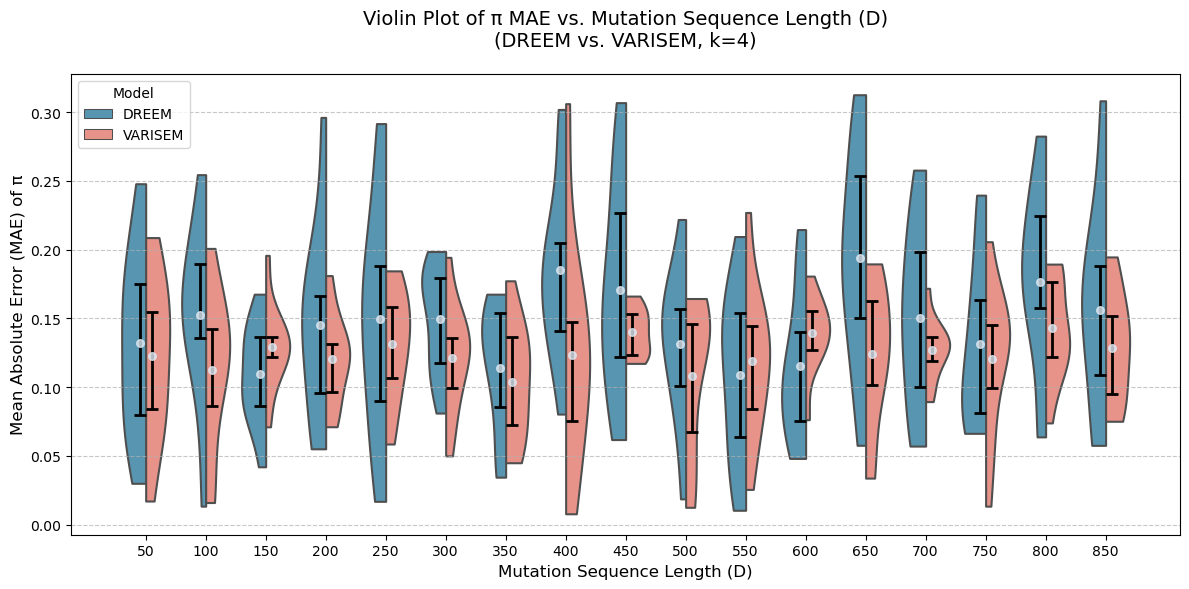

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count",
    cut=0,
    bw_adjust=2
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean#d8b03c
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)


plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "Figure2C2.pdf")
plt.savefig(filename, format='pdf')
plt.show()


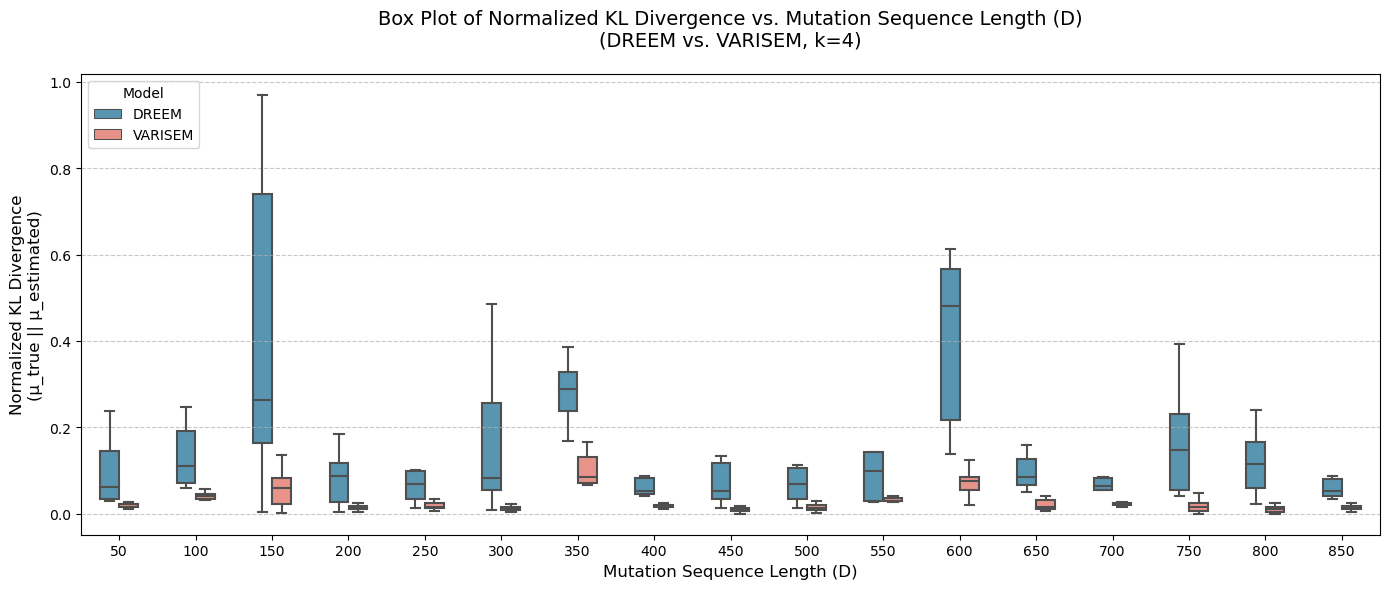

In [7]:
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM_norm", "mu_KL_VARISEM_norm"],
    var_name="Model",
    value_name="mu_KL_norm"
)

# Rename model labels
df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM_norm": "DREEM",
    "mu_KL_VARISEM_norm": "VARISEM"
})
# Filter out points at exactly 0 or 1 (to avoid extreme tails and distortions)
df_long_mu_kl_filtered = df_long_mu_kl[
    (df_long_mu_kl["mu_KL_norm"] > 0) & 
    (df_long_mu_kl["mu_KL_norm"] < 1)
].copy()
plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=df_long_mu_kl_filtered,
    x="D",
    y="mu_KL_norm",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    width=0.5,
    dodge=True,
    showfliers=False)  

plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Box Plot of Normalized KL Divergence vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()
filename = os.path.join(output_folder, "Figure2B.pdf")
plt.savefig(filename, format='pdf')
plt.show()


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename_dreem_csv = os.path.join("/Users/yanfeiwang/Desktop/DREEM/k=5", "DREEM_ARI_pi_mu_k=5.csv")
filename_varisem_csv = os.path.join("/Users/yanfeiwang/Desktop/DREEM/k=5", "VARISEM_ARI_pi_mu_k=5.csv")

# Now read from those files
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

In [12]:
# Melt pi_MAE columns into long format
df_long_pi_mae = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["pi_MAE_DREEM", "pi_MAE"],
    var_name="Model",
    value_name="pi_MAE_value"  # unique name to avoid conflict
)

# Clean up model names
df_long_pi_mae["Model"] = df_long_pi_mae["Model"].replace({
    "pi_MAE_DREEM": "DREEM",
    "pi_MAE": "VARISEM"
})

# Melt mu_KL columns into long format
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM", "mu_KL"],
    var_name="Model",
    value_name="mu_KL_value"  # unique name to avoid conflict
)

df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM": "DREEM",
    "mu_KL": "VARISEM"
})


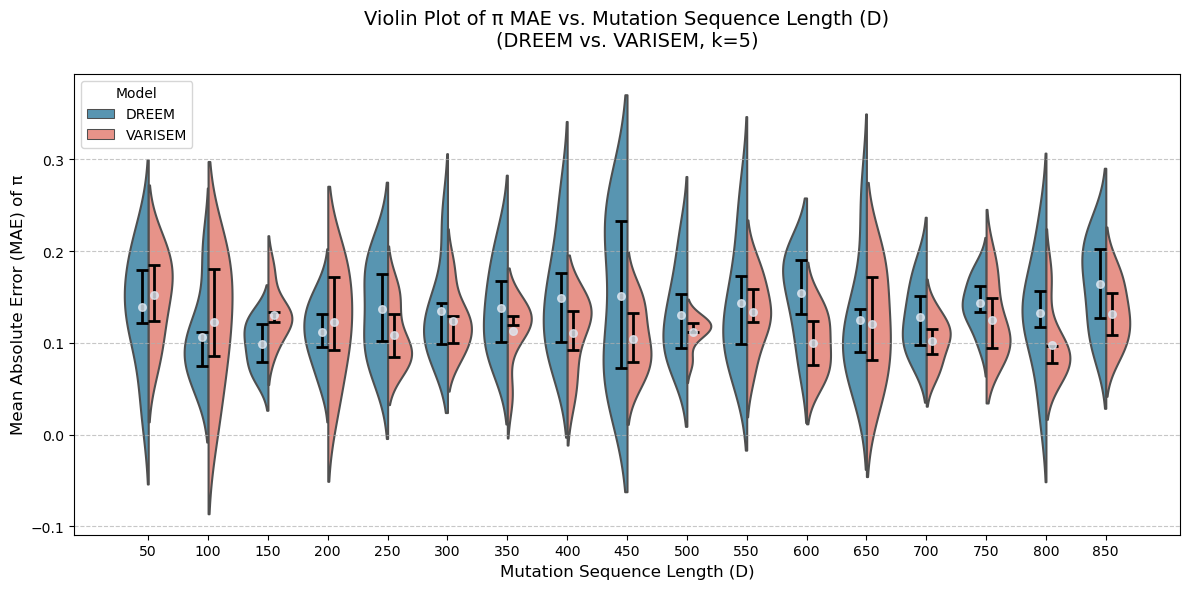

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count"
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean#d8b03c
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)


plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "Figure3C1.pdf")
plt.savefig(filename, format='pdf')
plt.show()


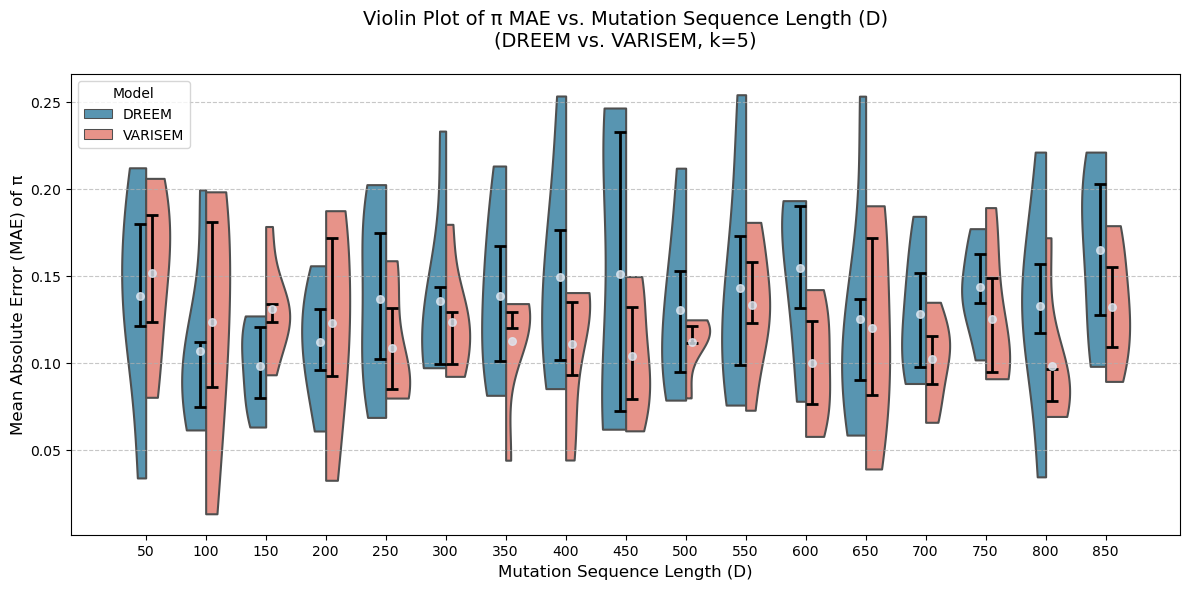

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the base violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_long_pi_mae,
    x="D",
    y="pi_MAE_value",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    split=True,
    inner=None,  # Turn off Seaborn’s default quartiles
    scale="count",
    cut=0,
    bw_adjust=2
)

# Summary statistics
summary = df_long_pi_mae.groupby(["D", "Model"]).agg(
    q1=("pi_MAE_value", lambda x: np.percentile(x, 25)),
    q3=("pi_MAE_value", lambda x: np.percentile(x, 75)),
    mean=("pi_MAE_value", "mean")
).reset_index()

# Plot parameters
spacing = 0.1        # Distance from center to the line
line_length = 0.2   # Length of horizontal lines

# Loop through each D
for i, d in enumerate(sorted(df_long_pi_mae["D"].unique())):
    # ---- DREEM (left side) ----
    dreem_row = summary[(summary["D"] == d) & (summary["Model"] == "DREEM")]
    if not dreem_row.empty:
        q1 = dreem_row["q1"].values[0]
        q3 = dreem_row["q3"].values[0]
        mean = dreem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i - spacing - line_length / 2, i - spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i - spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean#d8b03c
        ax.scatter(i - spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

    # ---- VARISEM (right side) ----
    varisem_row = summary[(summary["D"] == d) & (summary["Model"] == "VARISEM")]
    if not varisem_row.empty:
        q1 = varisem_row["q1"].values[0]
        q3 = varisem_row["q3"].values[0]
        mean = varisem_row["mean"].values[0]

        # Horizontal lines for q1 and q3 (remove for mean)
        ax.hlines(q1, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)
        ax.hlines(q3, i + spacing - line_length / 2, i + spacing + line_length / 2, color='black', linewidth=2)

        # Vertical line between q1 and q3 (IQR)
        ax.vlines(i + spacing, q1, q3, color='black', linewidth=2)

        # Small circle for mean
        ax.scatter(i + spacing, mean, color='#dee8f2', alpha=0.8, s=30, zorder=5)

# Labels and styling
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Violin Plot of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)
plt.legend(title="Model", loc="upper left")
plt.grid(axis='y', linestyle="--", alpha=0.7)


plt.tight_layout()

# Save the plot
filename = os.path.join(output_folder, "Figure3C2.pdf")
plt.savefig(filename, format='pdf')
plt.show()


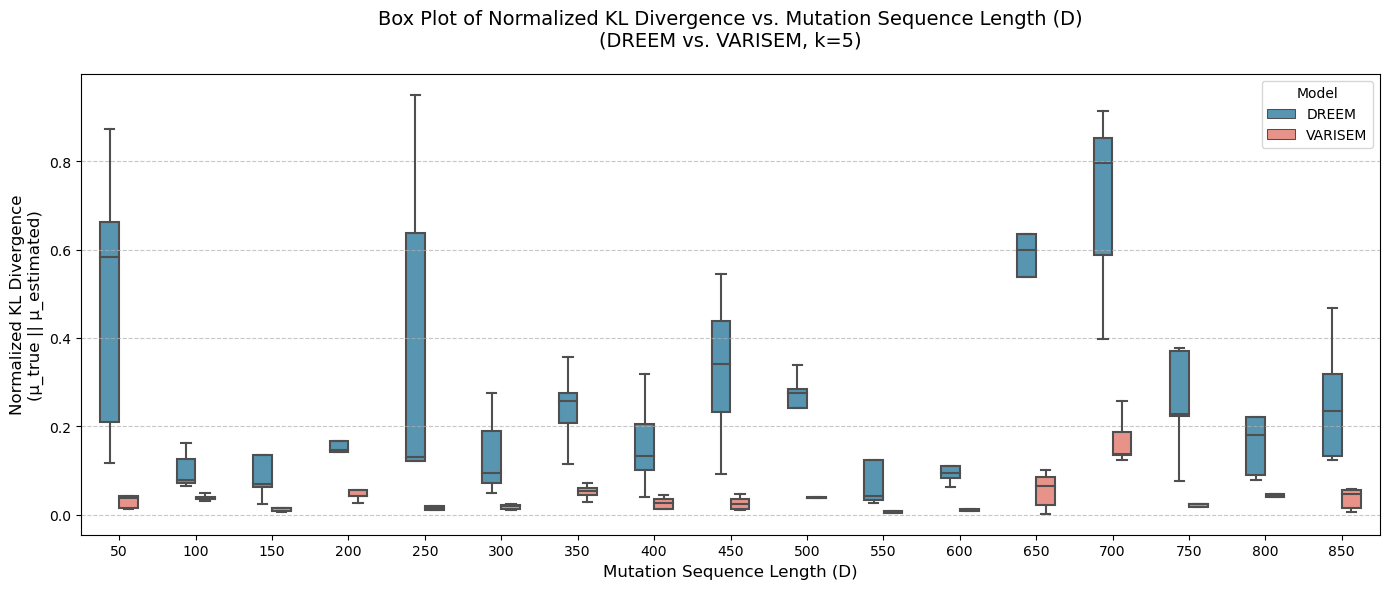

In [16]:
df_long_mu_kl = pd.melt(
    df_combined,
    id_vars=["D", "N"],
    value_vars=["mu_KL_DREEM_norm", "mu_KL_VARISEM_norm"],
    var_name="Model",
    value_name="mu_KL_norm"
)

# Rename model labels
df_long_mu_kl["Model"] = df_long_mu_kl["Model"].replace({
    "mu_KL_DREEM_norm": "DREEM",
    "mu_KL_VARISEM_norm": "VARISEM"
})
# Filter out points at exactly 0 or 1 (to avoid extreme tails and distortions)
df_long_mu_kl_filtered = df_long_mu_kl[
    (df_long_mu_kl["mu_KL_norm"] > 0) & 
    (df_long_mu_kl["mu_KL_norm"] < 1)
].copy()
plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=df_long_mu_kl_filtered,
    x="D",
    y="mu_KL_norm",
    hue="Model",
    palette={"DREEM": "#499bc0", "VARISEM": "#f78779"},
    width=0.5,
    dodge=True,
    showfliers=False)  

plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Box Plot of Normalized KL Divergence vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper right")
plt.tight_layout()
filename = os.path.join(output_folder, "Figure3B.pdf")
plt.savefig(filename, format='pdf')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting parameters
bar_width = 26
spacing =75

# Generate x-axis positions for each D value
x_labels = df_summary["D"]
x_positions = np.arange(len(x_labels)) * spacing

# Create the figure
plt.figure(figsize=(12, 6))

# Plot DREEM pi_MAE bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary["pi_MAE_DREEM_mean"],
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM pi_MAE bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary["pi_MAE_VARISEM_mean"],
    color="#f78779", 
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)

# Add value labels on top of each bar
for bar, value in zip(bars_dreem, df_summary["pi_MAE_DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,     # A small offset above the bar
        f"{value:.2f}",              # Format to 3 decimal places (adjust as needed)
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary["pi_MAE_VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Comparison of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)

# Customize ticks
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add grid and legend
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "pi_MAE_VARISEM_vs_DREEM_k=3.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


In [ ]:
# Plotting parameters
bar_width = 25
spacing = 60  # space between groups

# Generate x-axis positions for each D value
x_labels = df_summary_norm["D"]  # <--- use df_summary_norm here
x_positions = np.arange(len(x_labels)) * spacing

plt.figure(figsize=(12, 6))

# Plot DREEM normalized KL divergence bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary_norm["DREEM_mean"],  # <--- use df_summary_norm
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.65
)

# Plot VARISEM normalized KL divergence bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary_norm["VARISEM_mean"],  # <--- use df_summary_norm
    color="#f78779", 
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.65
)

# Add value labels for both bars
for bar, value in zip(bars_dreem, df_summary_norm["DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary_norm["VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Normalized KL Divergence of μ vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)

plt.xticks(x_positions, x_labels, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Y-axis limit adjustment
y_max = max(df_summary_norm["DREEM_mean"].max(), df_summary_norm["VARISEM_mean"].max()) + 0.1
plt.ylim(0, min(1, y_max))  # Cap the upper limit at 1 if necessary

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()

filename = os.path.join(output_folder, "mu_KL_normalized_VARISEM_vs_DREEM_k=3.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


In [ ]:
output_folder = "k=4"
os.makedirs(output_folder, exist_ok=True)
D_values = np.arange(50, 900, 50)
N_values = [50, 100, 150, 200, 250, 300, 400, 500, 600, 800,1000]

results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 4
        alpha = np.ones(K) * 2

        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        vi_model_bmm_mean = VARISEM(X_D, K, max_iter=300, tol=1e-6)
        vi_model_bmm_mean.fit()

        Z_pred = np.argmax(vi_model_bmm_mean.q_nk, axis=1)
        ari_score = adjusted_rand_score(Z_true, Z_pred)

        pi_estimated = vi_model_bmm_mean.pi_k_mean
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Compute KL divergence for mu
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], vi_model_bmm_mean.mu_ki_mean[k, :])
            kl_divergences.append(kl_k)
        kl_divergence_mean = np.mean(kl_divergences)

        results.append([D, N, ari_score, pi_mae, kl_divergence_mean])

# Create DataFrame
df_results = pd.DataFrame(results, columns=["D", "N", "ARI", "pi_MAE", "mu_KL"])
filename_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=4.csv")
df_results.to_csv(filename_csv, index=False)


In [ ]:
results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 4
        alpha = np.ones(K) * 2

        # Generate true parameters
        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        # Run DREEM
        dreem_model = DREEM(X_D, K, max_iter=300, tol=1e-6)
        dreem_model.fit()

        Z_pred_dreem = dreem_model.predict()
        ari_dreem = adjusted_rand_score(Z_true, Z_pred_dreem)

        # Calculate pi MAE
        pi_estimated = dreem_model.pi
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Calculate mu KL divergence
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], dreem_model.mu[k, :])
            kl_divergences.append(kl_k)
        mu_kl = np.mean(kl_divergences)

        results.append([D, N, ari_dreem, pi_mae, mu_kl])


df_results = pd.DataFrame(results, columns=["D", "N", "ARI_DREEM", "pi_MAE_DREEM", "mu_KL_DREEM"])
filename_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=4.csv")
df_results.to_csv(filename_csv, index=False)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=4.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=4.csv")
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)
df_combined["ARI_DREEM"] = df_combined["ARI_DREEM"].clip(lower=0)
df_combined["ARI"] = df_combined["ARI"].clip(lower=0)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Setup
bar_width = 0.35
x_positions = np.arange(len(df_summary["D"]))

plt.figure(figsize=(12, 6))

# Plot DREEM ARI
plt.bar(
    x_positions - bar_width / 2,
    df_summary["ARI_DREEM_mean"],
    yerr=[
        df_summary["ARI_DREEM_min_err"],
        df_summary["ARI_DREEM_max_err"]
    ],
    capsize=5,
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM ARI
plt.bar(
    x_positions + bar_width / 2,
    df_summary["ARI_VARISEM_mean"],
    yerr=[
        df_summary["ARI_VARISEM_min_err"],
        df_summary["ARI_VARISEM_max_err"]
    ],
    capsize=5,
    color="#f78779",  
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)


# Labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Comparison of ARI vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)
plt.xticks(x_positions, df_summary["D"], rotation=45, fontsize=10)

plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")

# Save and show the plot
plt.tight_layout()                  
filename = os.path.join(output_folder, "ARI_VARISEM_vs_DREEM_k=4.pdf")
plt.savefig(filename, format='pdf')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
output_folder = "k=4"
# Plotting parameters
bar_width = 26
spacing =75

# Generate x-axis positions for each D value
x_labels = df_summary["D"]
x_positions = np.arange(len(x_labels)) * spacing

# Create the figure
plt.figure(figsize=(12, 6))

# Plot DREEM pi_MAE bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary["pi_MAE_DREEM_mean"],
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM pi_MAE bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary["pi_MAE_VARISEM_mean"],
    color="#f78779", 
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)

# Add value labels on top of each bar
for bar, value in zip(bars_dreem, df_summary["pi_MAE_DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0035,     # A small offset above the bar
        f"{value:.2f}",              # Format to 3 decimal places (adjust as needed)
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary["pi_MAE_VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Comparison of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)

# Customize ticks
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add grid and legend
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "pi_MAE_VARISEM_vs_DREEM_k=4.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


In [ ]:
# Plotting parameters
bar_width = 25
spacing = 60  # space between groups

# Generate x-axis positions for each D value
x_labels = df_summary_norm["D"]  # <--- use df_summary_norm here
x_positions = np.arange(len(x_labels)) * spacing

plt.figure(figsize=(12, 6))

# Plot DREEM normalized KL divergence bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary_norm["DREEM_mean"],  # <--- use df_summary_norm
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.65
)

# Plot VARISEM normalized KL divergence bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary_norm["VARISEM_mean"],  # <--- use df_summary_norm
    color="#f78779", 
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.65
)

# Add value labels for both bars
for bar, value in zip(bars_dreem, df_summary_norm["DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary_norm["VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Normalized KL Divergence of μ vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)

plt.xticks(x_positions, x_labels, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Y-axis limit adjustment
y_max = max(df_summary_norm["DREEM_mean"].max(), df_summary_norm["VARISEM_mean"].max()) + 0.1
plt.ylim(0, min(1, y_max))  # Cap the upper limit at 1 if necessary

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()

filename = os.path.join(output_folder, "mu_KL_normalized_VARISEM_vs_DREEM_k=4.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename_dreem_csv = os.path.join("/Users/yanfeiwang/Desktop/DREEM/k=5", "DREEM_ARI_pi_mu_k=5.csv")
filename_varisem_csv = os.path.join("/Users/yanfeiwang/Desktop/DREEM/k=5", "VARISEM_ARI_pi_mu_k=5.csv")

# Now read from those files
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

output_folder = "k=5"
os.makedirs(output_folder, exist_ok=True)

bar_width = 0.35
x_positions = np.arange(len(df_summary["D"]))

plt.figure(figsize=(12, 6))

# Plot DREEM ARI
plt.bar(
    x_positions - bar_width / 2,
    df_summary["ARI_DREEM_mean"],
    yerr=[
        df_summary["ARI_DREEM_min_err"],
        df_summary["ARI_DREEM_max_err"]
    ],
    capsize=5,
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM ARI
plt.bar(
    x_positions + bar_width / 2,
    df_summary["ARI_VARISEM_mean"],
    yerr=[
        df_summary["ARI_VARISEM_min_err"],
        df_summary["ARI_VARISEM_max_err"]
    ],
    capsize=5,
    color="#f78779",  
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)


# Labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Comparison of ARI vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)
plt.xticks(x_positions, df_summary["D"], rotation=45, fontsize=10)

plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")

# Save and show the plot
plt.tight_layout()                  
filename = os.path.join(output_folder, "ARI_VARISEM_vs_DREEM_k=5.pdf")
plt.savefig(filename, format='pdf')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Plotting parameters
bar_width = 26
spacing =75

# Generate x-axis positions for each D value
x_labels = df_summary["D"]
x_positions = np.arange(len(x_labels)) * spacing

# Create the figure
plt.figure(figsize=(12, 6))

# Plot DREEM pi_MAE bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary["pi_MAE_DREEM_mean"],
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM pi_MAE bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary["pi_MAE_VARISEM_mean"],
    color="#f78779", 
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)

# Add value labels on top of each bar
for bar, value in zip(bars_dreem, df_summary["pi_MAE_DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,     # A small offset above the bar
        f"{value:.2f}",              # Format to 3 decimal places (adjust as needed)
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary["pi_MAE_VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Comparison of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)
plt.ylim(0, 0.2)
# Customize ticks
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add grid and legend
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "pi_MAE_VARISEM_vs_DREEM_k=5.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


In [ ]:
# Plotting parameters
bar_width = 25
spacing = 60  # space between groups

# Generate x-axis positions for each D value
x_labels = df_summary_norm["D"]  # <--- use df_summary_norm here
x_positions = np.arange(len(x_labels)) * spacing

plt.figure(figsize=(12, 6))

# Plot DREEM normalized KL divergence bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary_norm["DREEM_mean"],  # <--- use df_summary_norm
    color="#499bc0",  
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.65
)

# Plot VARISEM normalized KL divergence bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary_norm["VARISEM_mean"],  # <--- use df_summary_norm
    color="#f78779", 
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.65
)

# Add value labels for both bars
for bar, value in zip(bars_dreem, df_summary_norm["DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary_norm["VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Normalized KL Divergence of μ vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)

plt.xticks(x_positions, x_labels, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Y-axis limit adjustment
y_max = max(df_summary_norm["DREEM_mean"].max(), df_summary_norm["VARISEM_mean"].max()) + 0.1
plt.ylim(0, min(1, y_max))  # Cap the upper limit at 1 if necessary

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()

filename = os.path.join(output_folder, "mu_KL_normalized_VARISEM_vs_DREEM_k=5.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import digamma, logsumexp
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import adjusted_rand_score
from scipy.special import digamma, logsumexp, gammaln

class VARISEM:
    def __init__(self, X, K, max_iter=300, tol=1e-6, alpha_prior=None, a_prior=None, b_prior=None):
        self.X = X
        self.N, self.D = X.shape
        self.K = K
        self.max_iter = max_iter
        self.tol = tol

        # Set priors
        self.alpha_prior = alpha_prior if alpha_prior is not None else np.ones(K) * 2  # Weaker prior
        self.a_prior = a_prior if a_prior is not None else np.ones((K, D)) * 2  # Weaker prior for a
        self.b_prior = b_prior if b_prior is not None else np.ones((K, D)) * 5  # Weaker prior for b

        bmm = BayesianGaussianMixture(
            n_components=K, covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            random_state=42, max_iter=100, n_init=10
        )
        bmm.fit(X)
        self.q_nk = bmm.predict_proba(X)  


        # Initialize variational parameters
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.a_q = self.a_prior + np.dot(self.q_nk.T, X)
        self.b_q = self.b_prior + np.dot(self.q_nk.T, 1 - X)

        # Store ELBO values for monitoring
        self.elbo_values = []

    def update_q_nk(self):
        """Update responsibilities q_nk."""
        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        log_q_nk = log_pi_k + np.sum(
            self.X[:, None, :] * log_mu_ki[None, :, :] + (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :],
            axis=2
        )

        log_q_nk -= logsumexp(log_q_nk, axis=1, keepdims=True)
        self.q_nk = np.exp(log_q_nk)

    def update_pi_k(self):
        """Update cluster proportions pi_k."""
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.pi_k_mean = self.alpha_q / np.sum(self.alpha_q)

    def update_mu_ki(self):
        """Update mutation probabilities mu_ki."""
        self.a_q = self.a_prior + np.dot(self.q_nk.T, self.X)
        self.b_q = self.b_prior + np.dot(self.q_nk.T, 1 - self.X)
        self.mu_ki_mean = self.a_q / (self.a_q + self.b_q)

    def compute_elbo(self):
        """Compute the Evidence Lower Bound (ELBO)."""
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        # Log likelihood term
        log_likelihood = np.sum(self.q_nk[:, :, None] * (
            self.X[:, None, :] * log_mu_ki[None, :, :] +
            (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :]
        ))

        # Prior terms
        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))
        log_prior_z = np.sum(self.q_nk * log_pi_k)
        log_prior_pi = np.sum((self.alpha_prior - 1) * log_pi_k)
        log_prior_mu = np.sum((self.a_prior - 1) * log_mu_ki + (self.b_prior - 1) * log_1_mu_ki)

        # Entropy terms
        entropy_q_z = -np.sum(self.q_nk * np.log(self.q_nk + 1e-10))
        alpha_0 = np.sum(self.alpha_q)
        dirichlet_entropy = (
            gammaln(alpha_0) - np.sum(gammaln(self.alpha_q))
            + (alpha_0 - self.K) * digamma(alpha_0)
            - np.sum((self.alpha_q - 1) * digamma(self.alpha_q))
        )
        beta_entropy = np.sum(
            gammaln(self.a_q + self.b_q) - gammaln(self.a_q) - gammaln(self.b_q)
            - (self.a_q - 1) * digamma(self.a_q)
            - (self.b_q - 1) * digamma(self.b_q)
            + (self.a_q + self.b_q - 2) * digamma(self.a_q + self.b_q)
        )

        # ELBO
        elbo = (
            log_likelihood
            + log_prior_z
            + log_prior_pi
            + log_prior_mu
            + entropy_q_z
            + dirichlet_entropy
            + beta_entropy
        )

        return elbo

    def fit(self):
        """Fit the VARISEM model."""
        elbo_old = -np.inf
        self.elbo_values = []

        for iteration in range(self.max_iter):
            self.update_q_nk()
            self.update_pi_k()
            self.update_mu_ki()

            elbo = self.compute_elbo()
            self.elbo_values.append(elbo)

            if np.abs(elbo - elbo_old) < self.tol:
                break
            elbo_old = elbo

            if iteration % 10 == 0:
                print(f"Iteration {iteration}, ELBO: {elbo:.4f}")

        #print("Optimization complete.")

    def predict(self):
        """Predict cluster assignments."""
        return np.argmax(self.q_nk, axis=1)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.metrics import adjusted_rand_score

class DREEM:
    def __init__(self, X, K, max_iter=100, tol=1e-6):
        self.X = X
        self.N, self.D = X.shape
        self.K = K
        self.max_iter = max_iter
        self.tol = tol

        # Initialize parameters
        self.pi = np.ones(K) / K  # Uniform cluster proportions
        self.mu = np.random.rand(K, self.D)  # Random mutation probabilities
        self.responsibilities = np.zeros((self.N, self.K))  # Cluster responsibilities
        self.log_likelihoods = []

    def e_step(self):
        log_likelihood = np.zeros((self.N, self.K))
        for k in range(self.K):
            log_likelihood[:, k] = np.sum(
                self.X * np.log(np.clip(self.mu[k], 1e-10, 1 - 1e-10)) +
                (1 - self.X) * np.log(np.clip(1 - self.mu[k], 1e-10, 1 - 1e-10)),
                axis=1
            ) + np.log(self.pi[k] + 1e-10)

        log_responsibilities = log_likelihood - logsumexp(log_likelihood, axis=1, keepdims=True)
        self.responsibilities = np.exp(log_responsibilities)

    def m_step(self):
        N_k = np.sum(self.responsibilities, axis=0)
        self.pi = N_k / self.N
        for k in range(self.K):
            self.mu[k] = np.sum(self.responsibilities[:, k, None] * self.X, axis=0) / (N_k[k] + 1e-10)

    def compute_log_likelihood(self):
        log_likelihood = np.zeros((self.N, self.K))
        for k in range(self.K):
            log_likelihood[:, k] = np.sum(
                self.X * np.log(np.clip(self.mu[k], 1e-10, 1 - 1e-10)) +
                (1 - self.X) * np.log(np.clip(1 - self.mu[k], 1e-10, 1 - 1e-10)),
                axis=1
            ) + np.log(self.pi[k] + 1e-10)
        return np.sum(logsumexp(log_likelihood, axis=1))

    def fit(self):
        log_likelihood_old = -np.inf
        for iteration in range(self.max_iter):
            self.e_step()
            self.m_step()

            log_likelihood = self.compute_log_likelihood()
            self.log_likelihoods.append(log_likelihood)

            if np.abs(log_likelihood - log_likelihood_old) < self.tol:
                print(f"Converged at iteration {iteration}.")
                break
            log_likelihood_old = log_likelihood
        print("Optimization complete.")

    def predict(self):
        return np.argmax(self.responsibilities, axis=1)

In [34]:
# Simulation parameters
D = 50
N =100
K =3

np.random.seed(314)
alpha = np.ones(K) * 2

# True proportions and mutation probabilities
pi_true = np.random.dirichlet(alpha)
a, b = 2,5 


mu_true = np.random.beta(a, b, (K, D))

# Generate mutation data
Z_true = np.random.choice(K, size=N, p=pi_true)
X_D = np.zeros((N, D), dtype=int)

for n in range(N):
    cluster = Z_true[n]
    X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

In [35]:
vi_model_bmm_mean = VARISEM(X_D, K=K, max_iter=300, tol=1e-6)
vi_model_bmm_mean.fit()
pi_inferred_mean = vi_model_bmm_mean.pi_k_mean

dreem_model = DREEM(X_D, K=K, max_iter=300, tol=1e-6)
dreem_model.fit()
pi_inferred_dreem = dreem_model.pi


Iteration 0, ELBO: 3502.9252
Iteration 10, ELBO: 3484.3533
Iteration 20, ELBO: 3484.3230
Iteration 30, ELBO: 3484.3692
Iteration 40, ELBO: 3484.4000
Iteration 50, ELBO: 3484.4260
Iteration 60, ELBO: 3484.4513
Iteration 70, ELBO: 3484.4788
Iteration 80, ELBO: 3484.5080
Iteration 90, ELBO: 3484.5162
Iteration 100, ELBO: 3484.4397
Iteration 110, ELBO: 3484.3846
Iteration 120, ELBO: 3484.3676
Iteration 130, ELBO: 3484.3270
Iteration 140, ELBO: 3484.2994
Iteration 150, ELBO: 3484.2901
Iteration 160, ELBO: 3484.2876
Iteration 170, ELBO: 3484.2869
Iteration 180, ELBO: 3484.2868
Iteration 190, ELBO: 3484.2867
Converged at iteration 46.
Optimization complete.


Saved density_comparison/mu_density_k=3_D50_N100.pdf


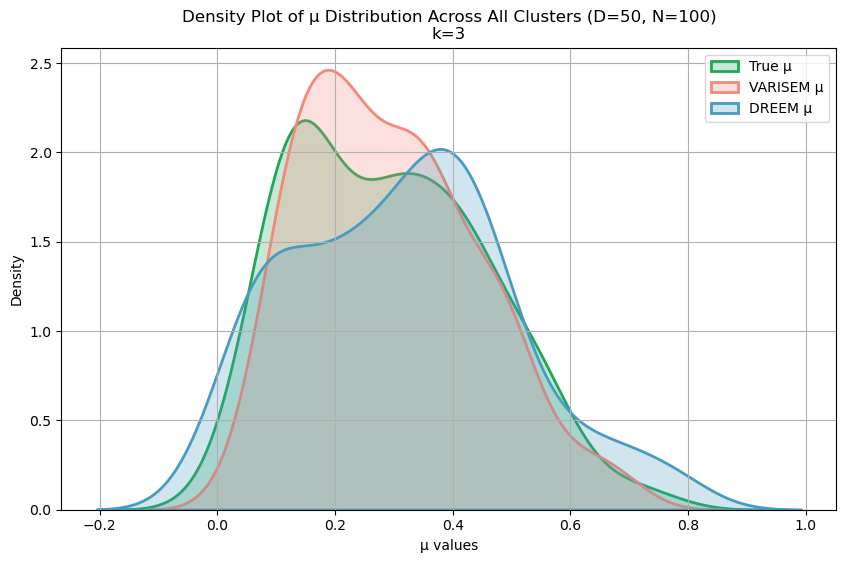

In [36]:
import seaborn as sns
import os
import matplotlib.pyplot as plt

# Create an output folder for the plots
output_folder = "density_comparison"
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(10, 6))


# Flatten arrays and plot combined densities '#FDD786'  
sns.kdeplot(mu_true.flatten(), label='True μ', fill=True, color='#1fa759', linewidth=2)
sns.kdeplot(vi_model_bmm_mean.mu_ki_mean.flatten(), label='VARISEM μ', fill=True, color='#f78779', linewidth=2)
sns.kdeplot(dreem_model.mu.flatten(), label='DREEM μ', fill=True, color='#499bc0', linewidth=2)

plt.title(f'Density Plot of μ Distribution Across All Clusters (D={D}, N={N})\nk=3')
plt.xlabel('μ values')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Save the global plot
filename = os.path.join(output_folder, f"mu_density_k=3_D{D}_N{N}.pdf")
plt.savefig(filename, format='pdf')
print(f"Saved {filename}")

plt.show()


In [37]:
# Simulation parameters
D = 50
N =100
K =4

np.random.seed(314)
alpha = np.ones(K) * 2

# True proportions and mutation probabilities
pi_true = np.random.dirichlet(alpha)
a, b = 2,5 


mu_true = np.random.beta(a, b, (K, D))

# Generate mutation data
Z_true = np.random.choice(K, size=N, p=pi_true)
X_D = np.zeros((N, D), dtype=int)

for n in range(N):
    cluster = Z_true[n]
    X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

In [38]:
vi_model_bmm_mean = VARISEM(X_D, K=K, max_iter=300, tol=1e-6)
vi_model_bmm_mean.fit()
pi_inferred_mean = vi_model_bmm_mean.pi_k_mean

dreem_model = DREEM(X_D, K=K, max_iter=300, tol=1e-6)
dreem_model.fit()
pi_inferred_dreem = dreem_model.pi



Iteration 0, ELBO: 3718.2547
Iteration 10, ELBO: 3686.8160
Iteration 20, ELBO: 3685.5393
Iteration 30, ELBO: 3684.3881
Iteration 40, ELBO: 3684.0881
Iteration 50, ELBO: 3681.9042
Iteration 60, ELBO: 3679.3835
Iteration 70, ELBO: 3671.7537
Iteration 80, ELBO: 3671.5831
Iteration 90, ELBO: 3671.1022
Iteration 100, ELBO: 3670.9951
Iteration 110, ELBO: 3671.2385
Iteration 120, ELBO: 3671.1880
Iteration 130, ELBO: 3671.0708
Iteration 140, ELBO: 3671.0734
Iteration 150, ELBO: 3671.0838
Iteration 160, ELBO: 3671.0888
Iteration 170, ELBO: 3671.0910
Iteration 180, ELBO: 3671.0919
Iteration 190, ELBO: 3671.0924
Iteration 200, ELBO: 3671.0926
Iteration 210, ELBO: 3671.0926
Iteration 220, ELBO: 3671.0927
Iteration 230, ELBO: 3671.0927
Converged at iteration 131.
Optimization complete.


Saved density_comparison/mu_density_k=4_D50_N100.pdf


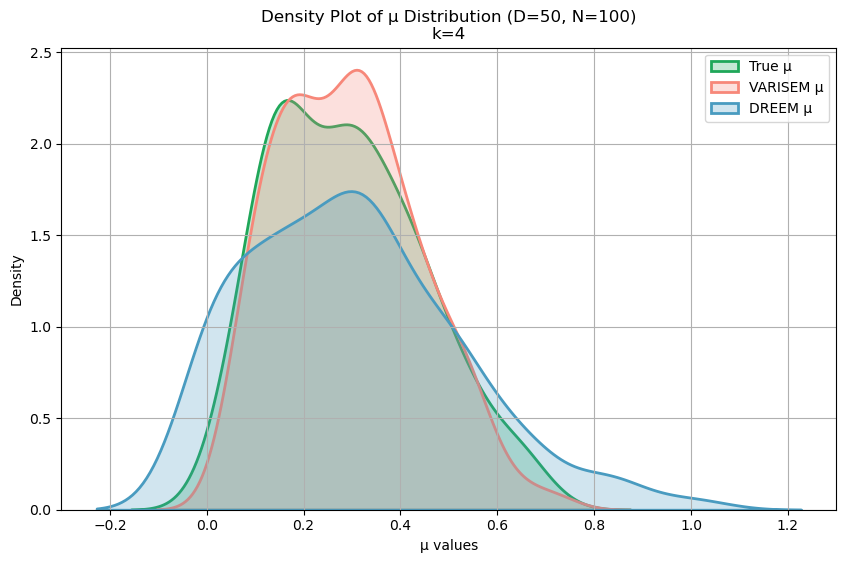

In [39]:
import seaborn as sns
import os
import matplotlib.pyplot as plt

# Global density plot across all clusters
plt.figure(figsize=(10, 6))

# Flatten arrays and plot combined densities
sns.kdeplot(mu_true.flatten(), label='True μ', fill=True, color='#1fa759', linewidth=2)
sns.kdeplot(vi_model_bmm_mean.mu_ki_mean.flatten(), label='VARISEM μ', fill=True, color='#f78779', linewidth=2)
sns.kdeplot(dreem_model.mu.flatten(), label='DREEM μ', fill=True, color='#499bc0', linewidth=2)

plt.title(f'Density Plot of μ Distribution (D={D}, N={N})\nk=4')
plt.xlabel('μ values')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Save the global plot
filename = os.path.join(output_folder, f"mu_density_k=4_D{D}_N{N}.pdf")
plt.savefig(filename, format='pdf')
print(f"Saved {filename}")

plt.show()


In [40]:
# Simulation parameters
D = 50
N =100
K =5

np.random.seed(314)
alpha = np.ones(K) * 2

# True proportions and mutation probabilities
pi_true = np.random.dirichlet(alpha)
a, b = 2,5 


mu_true = np.random.beta(a, b, (K, D))

# Generate mutation data
Z_true = np.random.choice(K, size=N, p=pi_true)
X_D = np.zeros((N, D), dtype=int)

for n in range(N):
    cluster = Z_true[n]
    X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

In [41]:
vi_model_bmm_mean = VARISEM(X_D, K=K, max_iter=300, tol=1e-6)
vi_model_bmm_mean.fit()
pi_inferred_mean = vi_model_bmm_mean.pi_k_mean

dreem_model = DREEM(X_D, K=K, max_iter=300, tol=1e-6)
dreem_model.fit()
pi_inferred_dreem = dreem_model.pi


Iteration 0, ELBO: 3887.6998
Iteration 10, ELBO: 3832.2604
Iteration 20, ELBO: 3830.1445
Iteration 30, ELBO: 3830.7408
Iteration 40, ELBO: 3829.5976
Iteration 50, ELBO: 3817.6861
Iteration 60, ELBO: 3814.3024
Iteration 70, ELBO: 3814.1041
Iteration 80, ELBO: 3813.5161
Iteration 90, ELBO: 3812.8774
Iteration 100, ELBO: 3812.9792
Iteration 110, ELBO: 3812.9936
Iteration 120, ELBO: 3812.9959
Iteration 130, ELBO: 3812.9962
Iteration 140, ELBO: 3812.9963
Converged at iteration 48.
Optimization complete.


Saved density_comparison/mu_density_k=5_D50_N100.pdf


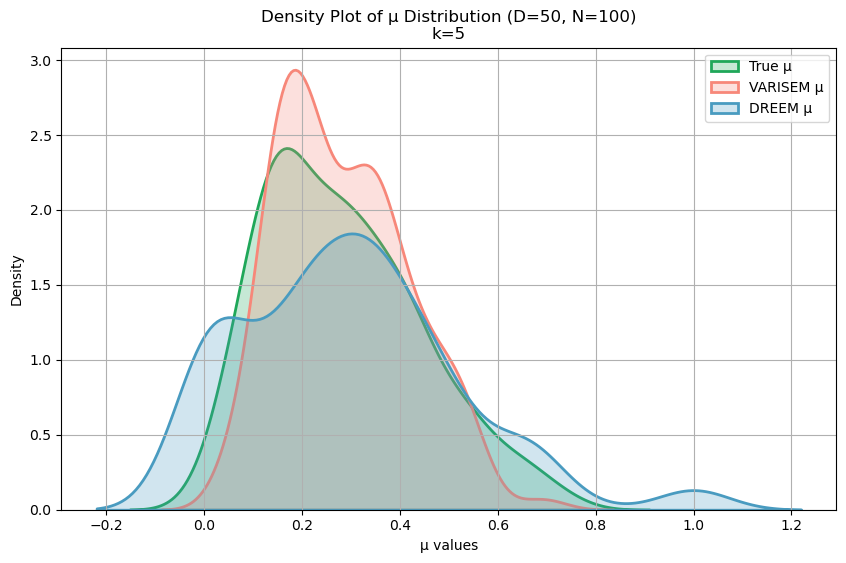

In [42]:
import seaborn as sns
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Flatten arrays and plot combined densities
sns.kdeplot(mu_true.flatten(), label='True μ', fill=True, color='#1fa759', linewidth=2)
sns.kdeplot(vi_model_bmm_mean.mu_ki_mean.flatten(), label='VARISEM μ', fill=True, color='#f78779', linewidth=2)
sns.kdeplot(dreem_model.mu.flatten(), label='DREEM μ', fill=True, color='#499bc0', linewidth=2)

plt.title(f'Density Plot of μ Distribution (D={D}, N={N})\nk=5')
plt.xlabel('μ values')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Save the global plot
filename = os.path.join(output_folder, f"mu_density_k=5_D{D}_N{N}.pdf")
plt.savefig(filename, format='pdf')
print(f"Saved {filename}")

plt.show()


In [43]:
# Simulation parameters
D = 50
N =100
K =6

np.random.seed(314)
alpha = np.ones(K) * 2

# True proportions and mutation probabilities
pi_true = np.random.dirichlet(alpha)
a, b = 2,5 


mu_true = np.random.beta(a, b, (K, D))

# Generate mutation data
Z_true = np.random.choice(K, size=N, p=pi_true)
X_D = np.zeros((N, D), dtype=int)

for n in range(N):
    cluster = Z_true[n]
    X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

In [44]:
vi_model_bmm_mean = VARISEM(X_D, K=K, max_iter=300, tol=1e-6)
vi_model_bmm_mean.fit()
pi_inferred_mean = vi_model_bmm_mean.pi_k_mean

dreem_model = DREEM(X_D, K=K, max_iter=300, tol=1e-6)
dreem_model.fit()
pi_inferred_dreem = dreem_model.pi


Iteration 0, ELBO: 4139.2488
Iteration 10, ELBO: 4108.6163
Iteration 20, ELBO: 4094.0609
Iteration 30, ELBO: 4093.5110
Iteration 40, ELBO: 4093.0752
Iteration 50, ELBO: 4092.9506
Iteration 60, ELBO: 4092.9261
Iteration 70, ELBO: 4092.9206
Iteration 80, ELBO: 4092.9194
Iteration 90, ELBO: 4092.9192
Iteration 100, ELBO: 4092.9191
Converged at iteration 20.
Optimization complete.


Saved density_comparison/mu_density_k=6_D50_N100.pdf


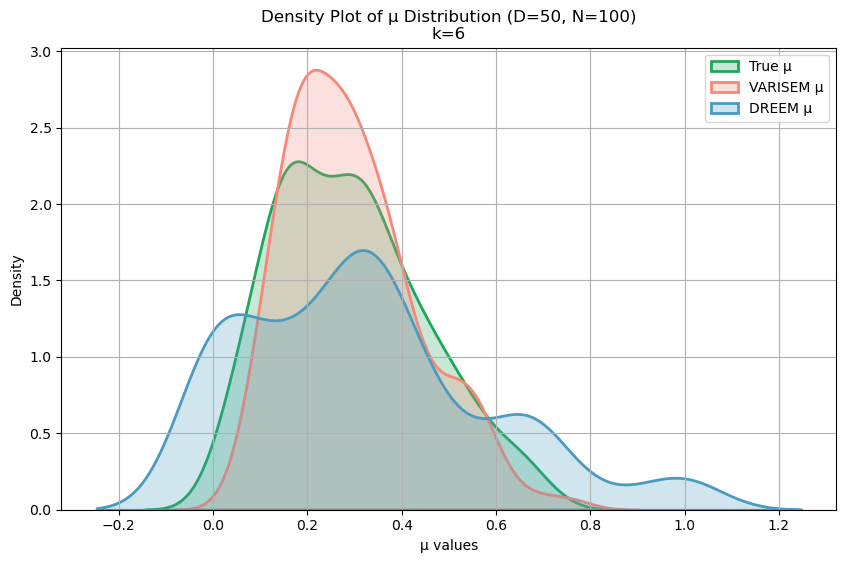

In [45]:
import seaborn as sns
import os
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

# Flatten arrays and plot combined densities
sns.kdeplot(mu_true.flatten(), label='True μ', fill=True, color='#1fa759', linewidth=2)
sns.kdeplot(vi_model_bmm_mean.mu_ki_mean.flatten(), label='VARISEM μ', fill=True, color='#f78779', linewidth=2)
sns.kdeplot(dreem_model.mu.flatten(), label='DREEM μ', fill=True, color='#499bc0', linewidth=2)

plt.title(f'Density Plot of μ Distribution (D={D}, N={N})\nk=6')
plt.xlabel('μ values')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Save the global plot
filename = os.path.join(output_folder, f"mu_density_k=6_D{D}_N{N}.pdf")
plt.savefig(filename, format='pdf')
print(f"Saved {filename}")

plt.show()
